# 02. Strategies, backtest, tests and results

This notebook follows notebook 01. It describes the two strategies, the backtest engine and the tests, then shows the **definitive results** (run on the delivered market data, D28). Every number is also in `results/RESULTS.md`.

> **Market data (D28).**
> - FX spot, 1-month forwards and 1-month NDFs: Bloomberg, default close (no 16:00 London fix).
> - MSCI World net TR, S&P 500 TR, DXY, Brent: Bloomberg; VIX: Cboe via WRDS.
> - 10-year yields: official sources (US Treasury, Bundesbank, Bank of England, MOF Japan).
> - **Timing**: signal at the 16:00 London snapshot, execution at the next close. That is the same day's New York close for the G10 and Latin America, and the next day's Asian close for KRW.
> - **Costs**: half of the delivered forward bid/ask spread (causal 20-day rolling median).
>
> The preliminary results on free data (D22) remain in `results/preliminary_free/` for comparison.

| Section | Content |
|---|---|
| 1 | Strategy A: variants, theory signs, fiscal regime |
| 2 | Strategy A: results, diagnostics, a posteriori additions and the D30 checks |
| 3 | Weekend test |
| 4 | Strategy B: EM carry (IRR 12-13 universe) with a PM geopolitical overlay |
| 5 | Strategy B: results, where the gap comes from (D29), a posteriori additions |
| 6 | Robustness and placebos |
| 7 | Risk, leverage, liquidity, and A versus B |
| 8 | Backtest engine and automated tests |
| 9 | Conclusions and open points |

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 60)
R = "results/"
P = "data/processed/"
def perf(path, keep):
    p = pd.read_csv(path)
    p = p[p["strategy"].isin(keep) & p["period"].isin(["in-sample", "out-of-sample", "full"])]
    cols = ["strategy", "period", "sharpe", "sharpe_t", "sharpe_ci90_low", "sharpe_ci90_high", "ann_mean", "ann_vol",
            "max_drawdown", "turnover_ann", "cost_drag_ann"]
    return p[[c for c in cols if c in p]].round(3)

## 1. Strategy A: variants, theory signs, fiscal regime

**Hypothesis.** Prediction markets continuously update expectations about monetary policy, fiscal policy and geopolitics. Their changes should show up in G10 currencies, with the signs given by the course's theory.

**Constraint revealed by the coverage table (D13).** Only US cells are covered, so the primary signal is a **dollar signal**. Three variants were declared before any backtest (D14), then separated from the information used by B (D17):

| Variant | Cells | Role |
|---|---|---|
| **A1** | US MONETARY, US FISCAL (sign depending on the regime) → G10 basket against USD | primary |
| A2 | every G10 cell (USD 10k threshold), each active when it has contracts | relaxed coverage |
| A3 | cells that pass the coverage rule (strict spec) | reduces to A1 |
| "+S" | adds geopolitics, tariffs and spillovers (JPY/CHF, NOK/CAD, AUD/NZD) | variants; these are the contracts of B's index |

**Theory signs** (effect of a rise in the signal on the zone's currency):

| Theme | Sign | Reasoning |
|---|---|---|
| MONETARY | + | More hawkish expectations, higher rates, stronger currency |
| INFLATION | + | An inflation-targeting central bank tightens |
| FISCAL_POLITICAL | + under monetary dominance, − under fiscal dominance | D15: the regime is observed, not fixed |
| TRADE_TARIFFS | − | Restriction suffered by the zone: terms of trade and growth |
| GEOPOLITICS (own zone) | − | Country risk |

**Fiscal regime (D15).** Rolling 60-day correlation between changes in the 10-year yield and in the currency, lagged one day. A negative correlation (yields up, currency down) signals fiscal dominance.

16:26:17 market QC: 903 values removed (431 flagged date-ticker pairs)


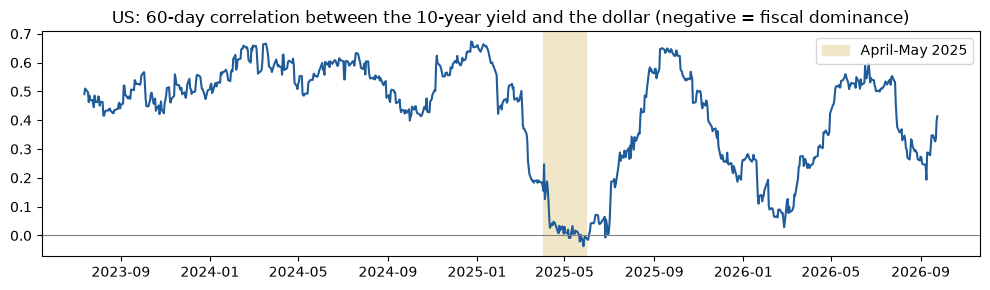

share of days in fiscal dominance (US) by year: {2023: 0.0, 2024: 0.0, 2025: 0.046, 2026: 0.0}


In [2]:
reg = pd.read_csv(R + "strategy_a/fiscal_regime.csv", index_col=0, parse_dates=True)
from src.common import load_config
from src.data import market
cfg = load_config()
raw, mp = market.read_raw(cfg), market.series_map(cfg)
days = pd.bdate_range("2023-06-01", cfg["sample"]["end"])
fx = market.fx_panel(raw, mp, ["EUR", "JPY", "GBP", "CHF", "AUD", "NZD", "CAD", "NOK", "SEK"], days)
usd = -np.log(fx.spot).mean(axis=1)
y10 = market.simple_series(raw, mp, "y10", days)["US"]
corr = y10.diff().rolling(60, min_periods=30).corr(usd.diff())
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(corr.index, corr, color="#1f5c99"); ax.axhline(0, color="grey", lw=0.8)
ax.axvspan(pd.Timestamp("2025-04-01"), pd.Timestamp("2025-05-31"), color="#f2e6c9", label="April-May 2025")
ax.set_title("US: 60-day correlation between the 10-year yield and the dollar (negative = fiscal dominance)"); ax.legend()
plt.tight_layout(); plt.show()
print("share of days in fiscal dominance (US) by year:", reg["US"].groupby(reg.index.year).mean().round(3).to_dict())

The correlation stays positive almost all the time: the indicator classifies the US as monetary dominance. It goes below zero only between early May and late June 2025, i.e. 4.6% of 2025 days.

**Finding (D27, exploratory).** The indicator is not retuned. The 2025 fiscal-dominance episode was too short for a 60-day rolling correlation. This is a result, not a setting to fix. Measurement limitation: the official US 10-year yield is taken around 15:30 New York and FX at the New York close, close but not identical times.

## 2. Strategy A: results and diagnostics

In [3]:
keep = ["A1_theory_with_dollar", "A1_theory_with_dollar_gross", "A2_theory_with_dollar", "A2_theory_with_dollar_gross",
        "A2_theory_dollar_neutral", "A1+S_theory_with_dollar", "A1+S_theory_dollar_neutral", "A1_theory_with_dollar_D12",
        "A1_gated_frozen"]
perf(R + "strategy_a/performance.csv", keep)

,strategy,period,sharpe,sharpe_t,sharpe_ci90_low,sharpe_ci90_high,ann_mean,ann_vol,max_drawdown,turnover_ann,cost_drag_ann
6,A1_theory_with_dollar,in-sample,0.485,0.699,-0.475,1.561,0.050,0.104,-0.135,115.374,0.042
7,A1_theory_with_dollar,out-of-sample,0.278,0.242,-2.911,1.892,0.030,0.108,-0.141,179.653,0.061
8,A1_theory_with_dollar,full,0.428,0.721,-0.704,1.221,0.045,0.105,-0.141,132.569,0.047
9,A1_theory_with_dollar_gross,in-sample,0.893,1.286,-0.068,1.961,0.092,0.103,-0.117,NaN,NaN
10,A1_theory_with_dollar_gross,out-of-sample,0.852,0.742,-2.252,2.494,0.091,0.107,-0.116,NaN,NaN
11,A1_theory_with_dollar_gross,full,0.882,1.485,-0.239,1.665,0.092,0.104,-0.117,NaN,NaN
12,A1_gated_frozen,in-sample,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN
13,A1_gated_frozen,out-of-sample,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN
14,A1_gated_frozen,full,NaN,NaN,NaN,NaN,0.000,0.000,0.000,NaN,NaN
15,A1+S_theory_dollar_neutral,in-sample,-0.136,-0.196,-1.491,1.022,-0.009,0.064,-0.109,184.484,0.080


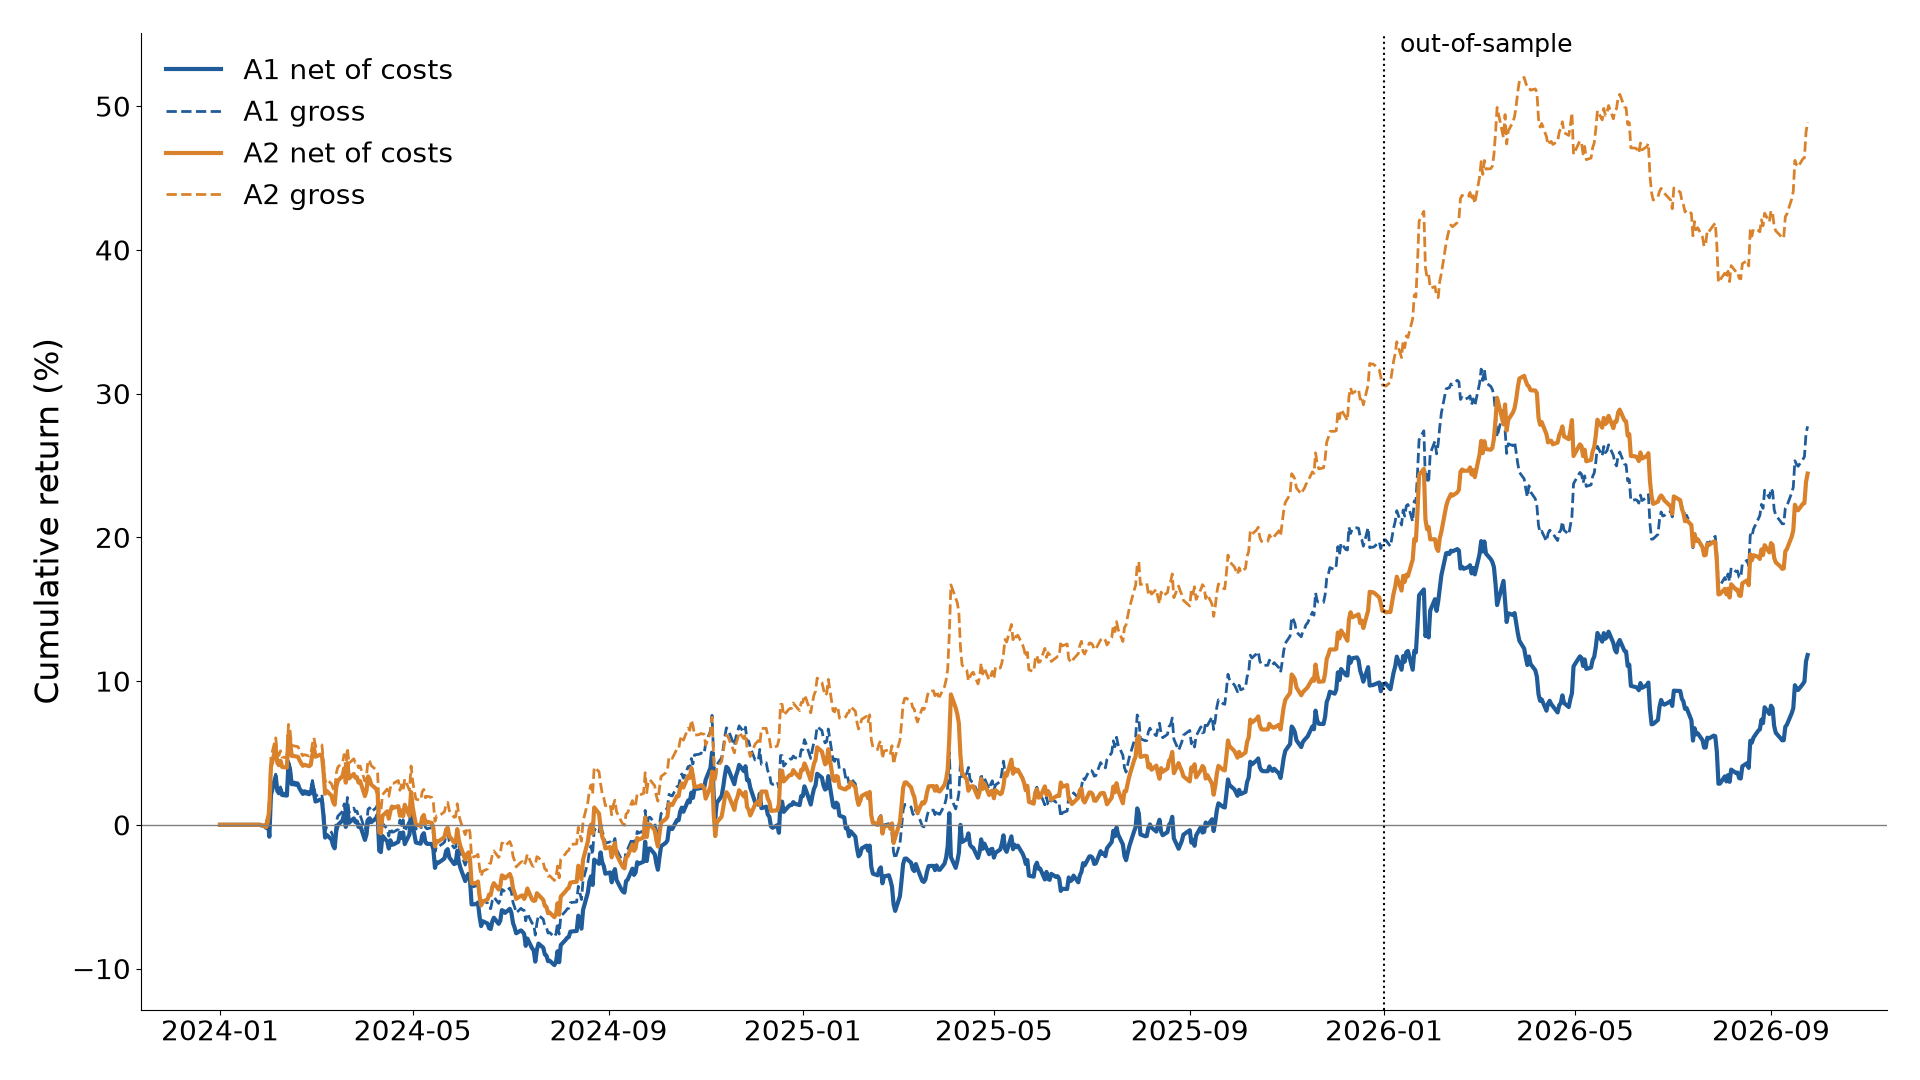

In [4]:
display(Image(R + "figures/slides/slide_a_cumulative.png", width=900))

Reading:
- **A1, dollar leg (primary)**: net Sharpe 0.43 over 2024-2026 (0.49 in 2024-2025, 0.28 in 2026). Gross: 0.88, t of 1.5, and a bootstrap interval that contains 0. The signal has content, but it is not significant on its own.
- **Costs eat half of the return**: turnover of about 130 times the exposure per year, i.e. about 4.7% of costs per year. Bloomberg closing spreads are wide for NOK and SEK (median half-spread of 11 to 12 bp): these costs are conservative. The net number therefore depends heavily on a cost assumption.
- **A2 (relaxed coverage)**: the best variant. Gross Sharpe 1.43, t of 2.4, bootstrap interval [0.37, 2.25]; net 0.81 (2026: 1.08). It is the only version of A whose interval excludes zero, and only before costs.
- **+S variants** (geopolitical spillovers): negative, as on free data. This supports D17.
- **D12** (demeaned probabilities instead of hazard rates): negative. The hazard-rate treatment matters.
- **Spec gated rule** (|t| > 3): no theme passes, so it does not trade (expected, D2).

**Diagnostics** (spec 6.4): pooled panel regressions, pair fixed effects, Driscoll-Kraay errors. Theory predicts positive coefficients.

In [5]:
d = pd.read_csv(R + "strategy_a/diagnostics.csv")
d[d.model.str.startswith(("A1_", "A2_"))][["model", "horizon", "regressor", "coef", "t", "n_obs"]].round(4)

,model,horizon,regressor,coef,t,n_obs
0,A1_predictive,1,MONETARY,0.0001,0.7481,6371
1,A1_predictive,1,FISCAL_POLITICAL,0.0001,0.9346,6371
2,A1_predictive,5,MONETARY,0.0005,1.0170,6151
3,A1_predictive,5,FISCAL_POLITICAL,0.0009,1.9177,6151
4,A1_predictive,20,MONETARY,-0.0008,-0.4565,5624
5,A1_predictive,20,FISCAL_POLITICAL,0.0036,3.3517,5624
6,A1_contemporaneous,0,MONETARY,0.0009,4.0238,6371
7,A1_contemporaneous,0,FISCAL_POLITICAL,0.0001,0.3277,6371
8,A1_fiscal_regime,1,_fiscal_raw,0.0001,0.9453,6371
9,A1_fiscal_regime,1,_fiscal_x_regime,-0.0015,-0.5695,6371


Key points:
- **Contemporaneous**: US MONETARY has a t of about 4. Hawkish prediction-market moves coincide with a stronger dollar on the same day. The number is a little lower than on free data (t ≈ 5), consistent with the six-hour gap between the PM day and the FX day (D28).
- **Predictive at 1 and 5 days**: the sign is the one theory predicts, but t stays below 2. No predictability at the spec's threshold.
- **US FISCAL at 20 days**: t of about 3.3. Suggestive, but it is a long horizon with overlapping returns, and one of many coefficients tested.
- **Fiscal × regime interaction**: cannot be interpreted, the regime is active only a few weeks.

**Static / timing decomposition (D25, pre-registered).** The static part holds the 2024-2025 average position constant. The timing part is the deviation from that average. Gross P&L.

In [6]:
d = pd.read_csv(R + "strategy_a/decomposition_static_timing.csv")
print(d[d.part.isin(["total", "static", "timing"])][["strategy", "part", "period", "sharpe", "sharpe_t", "sharpe_ci90_low", "sharpe_ci90_high", "ann_mean", "ann_vol"]].round(3).to_string(index=False))

             strategy   part        period  sharpe  sharpe_t  sharpe_ci90_low  sharpe_ci90_high  ann_mean  ann_vol
A1_theory_with_dollar  total     in-sample   0.893     1.286           -0.068             1.961     0.092    0.103
A1_theory_with_dollar  total out-of-sample   0.852     0.742           -2.252             2.494     0.091    0.107
A1_theory_with_dollar  total          full   0.882     1.485           -0.239             1.665     0.092    0.104
A1_theory_with_dollar static     in-sample   0.210     0.302           -0.878             1.232     0.005    0.024
A1_theory_with_dollar static out-of-sample   0.642     0.559           -1.604             2.203     0.015    0.023
A1_theory_with_dollar static          full   0.323     0.543           -0.743             1.113     0.008    0.023
A1_theory_with_dollar timing     in-sample   0.848     1.222           -0.102             1.888     0.087    0.103
A1_theory_with_dollar timing out-of-sample   0.719     0.626           -2.425   

A1's and A2's gross P&L comes almost entirely from timing. The static part is a small long-dollar position, around 2 to 3% volatility and about 1% annual return. A is therefore not a disguised dollar bet.

### A posteriori additions on A (partial lifting of the freeze, see `DECISIONS.md`)

Nothing below is pre-registered.
- **Weekly A1**: same positions, decided only on the last trading day of each week.
- **D30, gated rule at 20 days**: **the horizon was chosen after seeing the 20-day diagnostic on the full sample**, 2026 included. Estimation on 2024-2025, t > 3 with the right sign, frozen coefficients, rebalancing every 20 days, test on 2026.
- **Costs at 0.5x** the Bloomberg composite half-spread (the primary result stays at 1x).

In [7]:
perf(R + "strategy_a/performance.csv", ["A1_theory_with_dollar_weekly", "A1_theory_with_dollar_weekly_gross", "A1_gated20_frozen",
                                         "A1_gated20_frozen_gross", "A2_gated20_frozen", "A1_theory_with_dollar_cost0.5x",
                                         "A2_theory_with_dollar_cost0.5x"])

,strategy,period,sharpe,sharpe_t,sharpe_ci90_low,sharpe_ci90_high,ann_mean,ann_vol,max_drawdown,turnover_ann,cost_drag_ann
96,A1_theory_with_dollar_weekly,in-sample,0.870,1.254,-0.306,1.815,0.088,0.101,-0.091,57.052,0.021
97,A1_theory_with_dollar_weekly,out-of-sample,0.436,0.380,-1.914,1.903,0.048,0.109,-0.112,78.375,0.027
98,A1_theory_with_dollar_weekly,full,0.748,1.259,-0.309,1.595,0.077,0.103,-0.112,62.756,0.022
99,A1_theory_with_dollar_weekly_gross,in-sample,1.077,1.552,-0.126,2.022,0.109,0.101,-0.083,NaN,NaN
100,A1_theory_with_dollar_weekly_gross,out-of-sample,0.688,0.599,-1.640,2.153,0.074,0.108,-0.103,NaN,NaN
101,A1_theory_with_dollar_weekly_gross,full,0.969,1.631,-0.076,1.836,0.100,0.103,-0.103,NaN,NaN
102,A1_gated20_frozen,in-sample,1.163,1.676,0.264,2.010,0.125,0.107,-0.064,22.269,0.008
103,A1_gated20_frozen,out-of-sample,2.459,2.141,0.744,3.759,0.263,0.107,-0.052,26.899,0.009
104,A1_gated20_frozen,full,1.510,2.541,0.639,2.215,0.162,0.107,-0.064,23.508,0.009
105,A1_gated20_frozen_gross,in-sample,1.243,1.791,0.329,2.105,0.133,0.107,-0.063,NaN,NaN


In [8]:
pd.read_csv(R + "strategy_a/gate20_estimation.csv")[["variant", "regressor", "coef", "t", "n_obs", "passes_gate"]].round(4)

,variant,regressor,coef,t,n_obs,passes_gate
0,A1,MONETARY,-0.0006,-0.3489,4158,False
1,A1,FISCAL_POLITICAL,0.0036,3.1486,4158,True
2,A2,MONETARY,-0.0000,-0.0213,4158,False
3,A2,INFLATION,-0.0039,-2.1468,4158,False
4,A2,FISCAL_POLITICAL,0.0031,2.8343,4158,False


Reading:
- **Weekly**: A1's turnover falls from about 130 to 63 per year and the net Sharpe rises from 0.43 to 0.75. A good part of A1's net weakness came from the rebalancing frequency.
- **Costs at 0.5x**: A1 at 0.65, A2 at 1.12. The cost assumption matters as much as the signal.
- **D30**: only US FISCAL passes for A1 (t = 3.15 on 2024-2025); nothing passes for A2 (t = 2.83), which therefore does not trade. The 20-day gated A1 makes a net Sharpe of 1.51 over 2024-2026 and 2.46 in 2026. The checks below show how fragile that is.

**Checks of D30 (final review, no rule changed).** Phase robustness over the 20 possible start dates of the 20-day rebalancing, and an OLS on the dollar basket with non-overlapping 20-day returns.

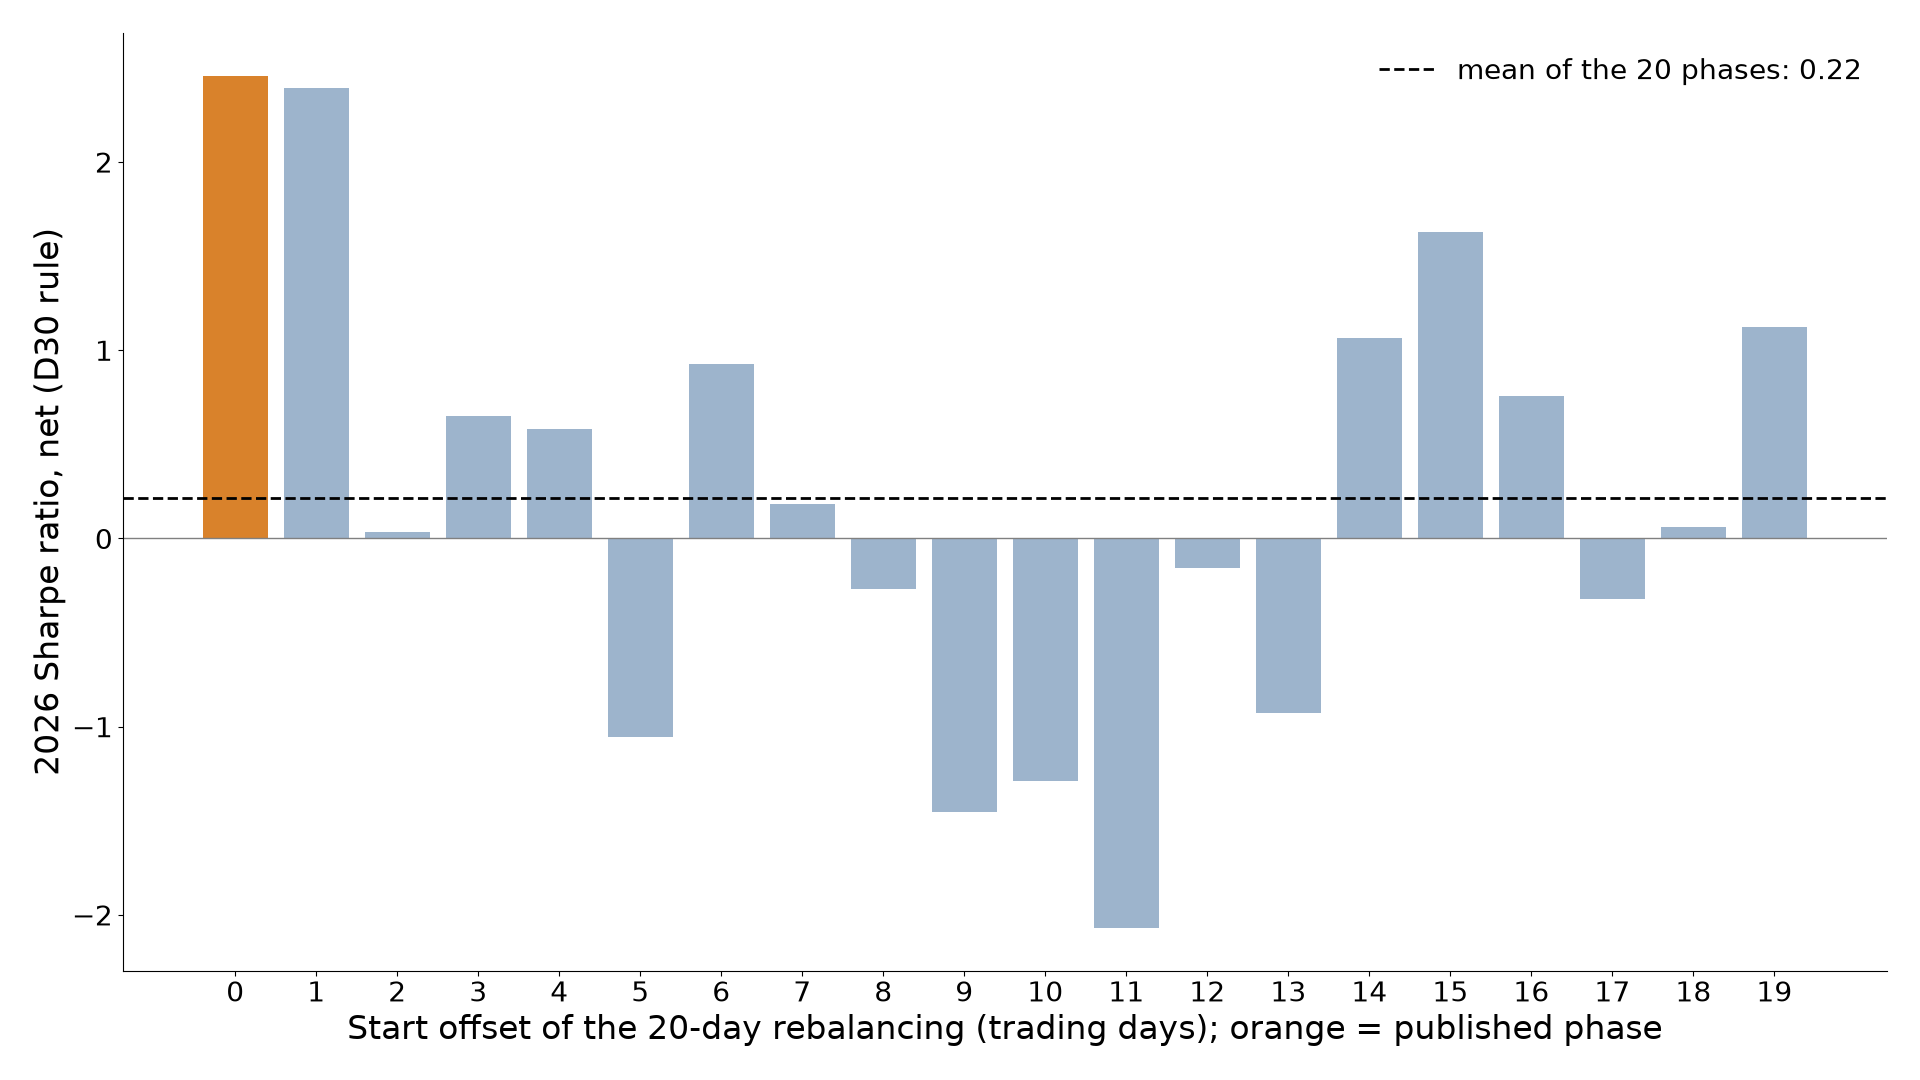

2026 Sharpe: published phase 2.46 | mean of the 20 phases 0.22 | phases > 0: 12 of 20
   period  n  coef     t     p
2024-2025 23 0.957 1.341 0.194
     2026  8 1.786 0.721 0.498


In [9]:
display(Image(R + "figures/slides/slide_d30_phase.png", width=900))
ph = pd.read_csv(R + "strategy_a/d30_checks/phase.csv")
print("2026 Sharpe: published phase", round(ph.sharpe_2026.iloc[0], 2), "| mean of the 20 phases", round(ph.sharpe_2026.mean(), 2),
      "| phases > 0:", int((ph.sharpe_2026 > 0).sum()), "of", len(ph))
eff = pd.read_csv(R + "strategy_a/d30_checks/effective_sample.csv")
print(eff[eff.offset == 0][["period", "n", "coef", "t", "p"]].round(3).to_string(index=False))

The published phase is the best of the 20 in every period; averaged over phases, the 2026 Sharpe is about 0.2, and the effective-sample regression is not significant. **D30 is an exploratory lead, not a result.**

## 3. Weekend test

FX is closed from Friday 17:00 to Sunday 17:00 New York while prediction markets keep moving. This is the cleanest identification: if weekend PM changes predict the reopening gap, the signal carries information FX does not have yet.

**Pre-registered specification (D24).**
- **Variant `A1+GEO`**: US MONETARY, US FISCAL, and GLOBAL GEOPOLITICS on its spillover currencies (JPY, CHF).
- **Gap**: from Friday 17:00 New York to Monday 07:00 London (`london` rows), from Dukascopy hourly prices; robustness at Sunday 18:00 New York (`ny` rows).
- **Sample**: every weekend since 2024.

In [10]:
w = pd.read_csv(R + "weekend/weekend_gap_regressions.csv")
w[["model", "regressor", "coef", "t", "n_obs"]].round(4)

,model,regressor,coef,t,n_obs
0,A1+GEO_weekend_gap_london,MONETARY,0.0000,0.0035,1278
1,A1+GEO_weekend_gap_london,FISCAL_POLITICAL,0.0001,0.5860,1278
2,A1+GEO_weekend_gap_london,SPILL_GLOBAL_GEOPOLITICS,-0.0002,-0.6230,1278
3,A1+GEO_weekend_gap_ny,MONETARY,0.0005,1.2682,1272
4,A1+GEO_weekend_gap_ny,FISCAL_POLITICAL,-0.0001,-0.6381,1272
5,A1+GEO_weekend_gap_ny,SPILL_GLOBAL_GEOPOLITICS,0.0001,0.7356,1272
6,A1_weekend_gap_london,MONETARY,0.0000,0.0254,1278
7,A1_weekend_gap_london,FISCAL_POLITICAL,0.0001,0.5231,1278
8,A1_weekend_gap_ny,MONETARY,0.0005,1.2585,1272
9,A1_weekend_gap_ny,FISCAL_POLITICAL,-0.0001,-0.5960,1272


Reading:
- **Pre-registered `A1+GEO` specification**: no significant coefficient (|t| < 1.3), neither at the London nor at the New York reopening. **Null result**: weekend PM changes do not predict the FX gap.
- **A1+S, China tariffs, New York reopening**: t of about 3.5. It is one variant among about forty coefficients, and it does not hold at the London reopening (t ≈ 1.4): to be read as a likely multiple-testing false positive.

## 4. Strategy B: EM carry (IRR 12-13 universe) with a PM geopolitical overlay

**Hypothesis.** EM carry earns a crash-risk premium (UIP failure, downside-risk CAPM). Part of these crashes is geopolitical. Prediction markets revise the probability of escalation before the realised shock, whereas VIX reacts when the shock happens.

**Base portfolio.**
- At each month-end, EM currencies are sorted by 1-month carry.
- Long the top tercile, short the bottom tercile (D23).
- Risk weighting (inverse 60-day volatility), 10% volatility target.

**Overlay.**
- **Exposure**: w(t), between 0 and 1, multiplies the base portfolio.
- **Escalation component, monthly (D16)**: w = 1 if the z-score is below 1, 0.5 between 1 and 2, 0 above 2.
- **Confirmed shock**: immediate cut to 0.25.
- **Re-risk**: linear return over 10 days.
- **Benchmark**: the same rule driven by VIX.

In [11]:
ex = pd.read_csv("data/manual/em_exclusions.csv", comment="#")
print(ex[["ccy", "irr_fine_code", "irr_label", "exclude", "exclude_variant_coarse12", "exclude_previous"]].to_string(index=False))

ccy  irr_fine_code                           irr_label  exclude  exclude_variant_coarse12  exclude_previous
BRL           12.0                    managed floating        0                         0                 0
MXN           13.0                     freely floating        0                         0                 0
COP           12.0                    managed floating        0                         0                 0
CLP           12.0                    managed floating        0                         0                 0
PEN            8.0        de facto crawling band <= 2%        1                         1                 0
ZAR           13.0                     freely floating        0                         0                 0
TRY           14.0                      freely falling        1                         1                 0
PLN           11.0                   moving band <= 2%        1                         0                 0
HUF            8.0        de

**Universe (D23, pre-registered).** Spec 7.2 is applied literally with the de facto classification of Ilzetzki, Reinhart and Rogoff, 2019 vintage.
- **Rule**: keep managed floating (code 12) and freely floating (code 13). Exclude pegs, crawling pegs, all narrow or moving bands, "freely falling" (TRY) and unclassified currencies (TWD).
- **Reason**: a managed currency has artificially low volatility. Inverse-volatility weighting overweights it although its real risk is devaluation.
- **Portfolio**: six currencies (BRL, MXN, COP, CLP, ZAR, KRW), hence 2 versus 2.

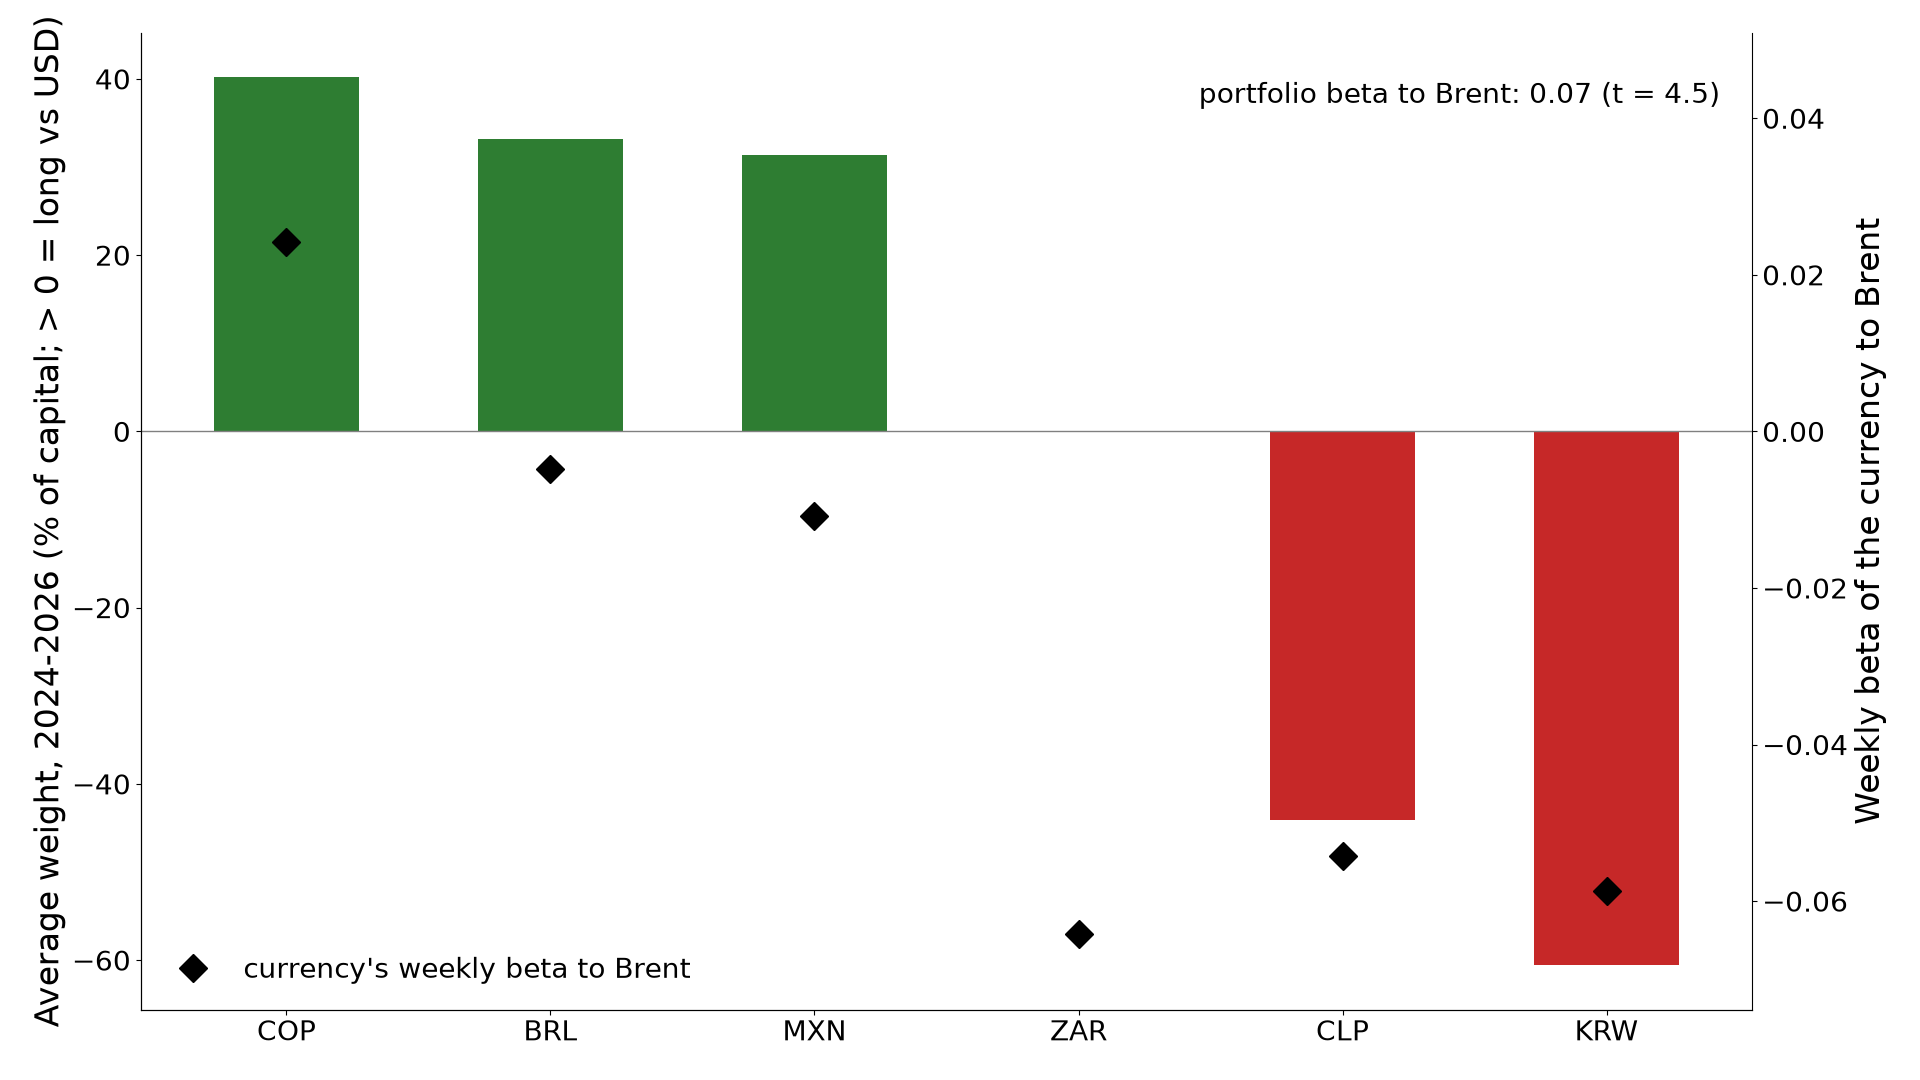

Base carry over the long history (2010-2026):
   n_days  sharpe  ann_mean  ann_vol  max_drawdown   skew
0    4365   0.331     0.035    0.107        -0.437 -0.188


In [12]:
display(Image(R + "figures/slides/slide_b_composition.png", width=900))
print("Base carry over the long history (2010-2026):")
print(pd.read_csv(R + "strategy_b/base_carry_long_history.csv")[["n_days", "sharpe", "ann_mean", "ann_vol", "max_drawdown", "skew"]].round(3))

Two findings.
- **Composition 2024-2026**: the portfolio is long COP, BRL and MXN, and always short KRW and CLP; ZAR stays in the middle tercile. The portfolio has a positive Brent beta (t of about 4.5, section 7). Taken one by one, only COP has a positive Brent beta over 2024-2026; BRL and MXN are close to zero. The portfolio's beta comes mostly from the short legs: KRW (an oil importer) and CLP fall when oil rises.
- **Long history (2010-2026)**: Sharpe 0.33, maximum drawdown −44%, negative skewness. This is the crash-risk premise of the strategy. Asian NDFs are discarded before 2011 (erratic points, D28).

## 5. Strategy B: results

In [13]:
perf(R + "strategy_b/performance.csv", ["base_carry", "pm_timed", "vix_timed", "pm_timed_level_misspecified", "pm_timed_prob_index_D12",
                                         "base_carry__coarse12", "pm_timed__coarse12", "base_carry__previous", "pm_timed__previous"])

,strategy,period,sharpe,sharpe_t,sharpe_ci90_low,sharpe_ci90_high,ann_mean,ann_vol,max_drawdown,turnover_ann,cost_drag_ann
0,base_carry,in-sample,0.953,1.372,-0.035,2.077,0.098,0.103,-0.140,8.004,0.004
1,base_carry,out-of-sample,2.028,1.765,0.553,3.749,0.217,0.107,-0.051,2.840,0.002
2,base_carry,full,1.249,2.102,0.327,2.314,0.130,0.104,-0.140,6.623,0.004
3,pm_timed,in-sample,0.995,1.433,-0.096,2.102,0.085,0.085,-0.080,22.179,0.014
4,pm_timed,out-of-sample,2.040,1.776,0.433,3.632,0.200,0.098,-0.051,19.976,0.011
5,pm_timed,full,1.303,2.193,0.418,2.266,0.116,0.089,-0.080,21.590,0.013
6,vix_timed,in-sample,0.857,1.235,-0.158,2.086,0.080,0.093,-0.116,25.150,0.016
7,vix_timed,out-of-sample,1.839,1.601,0.302,3.549,0.176,0.096,-0.051,22.358,0.013
8,vix_timed,full,1.125,1.893,0.148,2.192,0.106,0.094,-0.116,24.403,0.015
9,pm_timed_level_misspecified,in-sample,1.071,1.543,0.090,2.121,0.067,0.062,-0.054,16.770,0.010


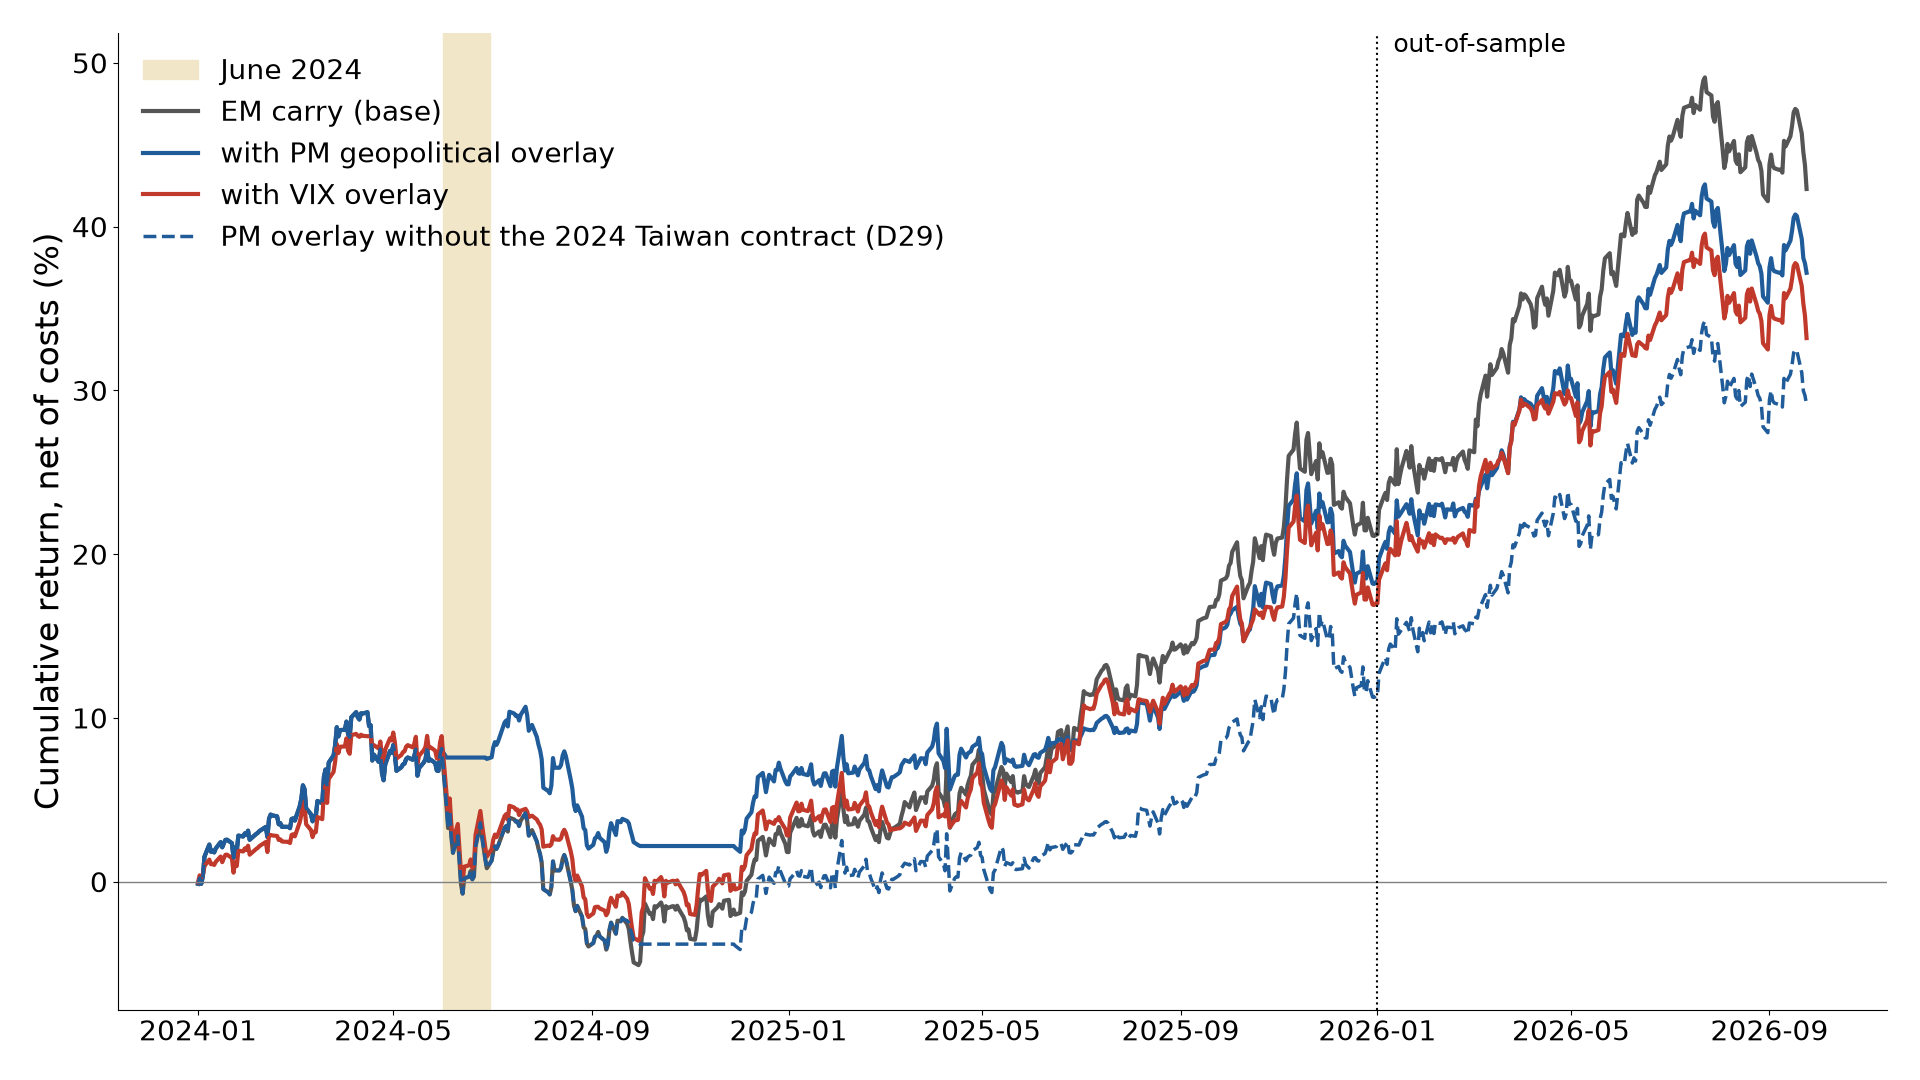

In [14]:
display(Image(R + "figures/slides/slide_b_cumulative.png", width=900))

At first sight the PM overlay beats the base carry: Sharpe 1.30 versus 1.25, and above all a maximum drawdown of −8% versus −14%. The VIX overlay does worse (1.12).

**Where does the gap come from? (D29, a posteriori diagnostic.)** The gap is decomposed month by month, then the event that triggered the decisive cut is removed.

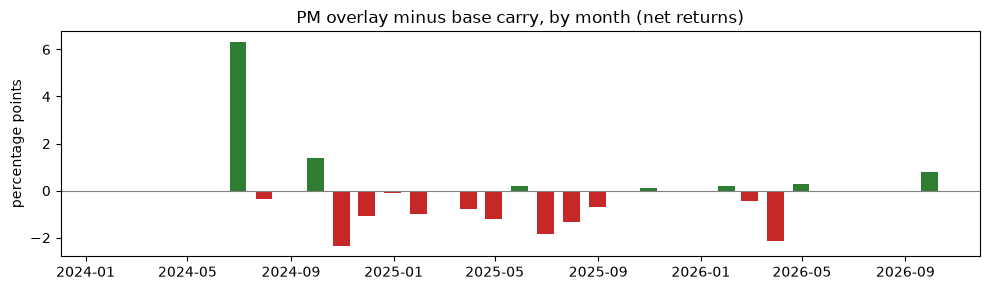

              strategy  sharpe  ann_mean  max_drawdown
            base_carry   1.249     0.130        -0.140
              pm_timed   1.303     0.116        -0.080
pm_timed_without_event   1.001     0.095        -0.131
decisive month: 2024-06 | event removed: will-china-invade-taiwan-in-2024 | contracts: 1


In [15]:
r = pd.read_parquet(R + "strategy_b/returns.parquet")
diff = (r["pm_timed"] - r["base_carry"]).resample("ME").sum()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(diff.index, 100 * diff.values, width=20, color=np.where(diff > 0, "#2e7d32", "#c62828"))
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("percentage points")
ax.set_title("PM overlay minus base carry, by month (net returns)")
plt.tight_layout(); plt.show()
km = pd.read_csv(R + "strategy_b/key_month_check.csv")
print(km[["strategy", "sharpe", "ann_mean", "max_drawdown"]].round(3).to_string(index=False))
print("decisive month:", km.best_month[0], "| event removed:", km.event_removed[0], "| contracts:", km.event_contracts[0])

Reading, which changes the conclusion on B:
- **The whole advantage comes from one month.** Over 2024-2026 the PM overlay loses about 4 cumulative points against the base carry, although it gains +6.3 in June 2024. Outside June 2024 it costs about 10 points.
- **The trigger** is a single Polymarket contract, "Will China invade Taiwan in 2024". It rises during the Chinese drills around Taiwan on 23 and 24 May 2024. The escalation z-score jumps above 9, and the rule sets w = 0 for June. It is a real escalation, captured as designed.
- **But the gain comes from elsewhere**: June 2024 is the fall of the Mexican peso after the 2 June election, unrelated to Taiwan. Without this contract the PM overlay falls to a Sharpe of 1.00 and a drawdown of −13%, below the base carry.
- **Economic reason**: this portfolio gains when oil rises (short KRW and CLP, long COP). A Middle East escalation lifts oil and helps it instead of crashing it (base-carry Sharpe close to 4 on geopolitical shock days; +8% during the 2026 Iran war). Cutting exposure on these shocks removes a natural hedge.

**Conclusion on B**: the base EM carry works over 2024-2026 (Sharpe 1.25, t of 2.1). However, **nothing shows that the PM geopolitical overlay adds value**, and the VIX overlay does not either. The apparent drawdown improvement rests on a coincidence.

### A posteriori additions on B (partial lifting of the freeze)
- **B2 (spec 7.5)**: mechanism and direction pre-specified in the spec, details fixed after seeing the oil exposure. A shock carried more than half by "oil" contracts does not cut the carry: it adds a tilt long BRL, MXN, COP against KRW, sized by the avoided cut.
- **Brent benchmark**: same rule, oil shock triggered by a Brent rise of more than 2 standard deviations.
- **D31, at least 3 distinct events per day** for the index, the escalation measure and shock confirmation (robustness motivated by D29).

In [16]:
perf(R + "strategy_b/performance.csv", ["base_carry", "pm_timed", "b2_oil_tilt", "b2_brent_tilt", "pm_timed_min3events"])

,strategy,period,sharpe,sharpe_t,sharpe_ci90_low,sharpe_ci90_high,ann_mean,ann_vol,max_drawdown,turnover_ann,cost_drag_ann
0,base_carry,in-sample,0.953,1.372,-0.035,2.077,0.098,0.103,-0.140,8.004,0.004
1,base_carry,out-of-sample,2.028,1.765,0.553,3.749,0.217,0.107,-0.051,2.840,0.002
2,base_carry,full,1.249,2.102,0.327,2.314,0.130,0.104,-0.140,6.623,0.004
3,pm_timed,in-sample,0.995,1.433,-0.096,2.102,0.085,0.085,-0.080,22.179,0.014
4,pm_timed,out-of-sample,2.040,1.776,0.433,3.632,0.200,0.098,-0.051,19.976,0.011
5,pm_timed,full,1.303,2.193,0.418,2.266,0.116,0.089,-0.080,21.590,0.013
48,b2_oil_tilt,in-sample,1.084,1.561,0.025,2.132,0.104,0.096,-0.107,23.514,0.016
49,b2_oil_tilt,out-of-sample,2.037,1.773,0.507,3.462,0.236,0.116,-0.051,19.277,0.013
50,b2_oil_tilt,full,1.370,2.306,0.535,2.318,0.140,0.102,-0.107,22.380,0.015
54,b2_brent_tilt,in-sample,1.075,1.548,0.029,2.112,0.104,0.096,-0.098,19.354,0.012


In [17]:
print(pd.read_csv(R + "strategy_b/posthoc_b2_min3_info.csv").to_string(index=False))
rb = pd.read_parquet(R + "strategy_b/returns.parquet")
att = {n: {"cumulative gap": 100 * (rb[n] - rb.base_carry).sum(), "of which June 2024": 100 * (rb[n] - rb.base_carry).loc["2024-06"].sum()}
       for n in ["pm_timed", "b2_oil_tilt", "b2_brent_tilt", "pm_timed_min3events"]}
pd.DataFrame(att).T.assign(**{"excluding June 2024": lambda d: d["cumulative gap"] - d["of which June 2024"]}).round(1)

                                item                                                                                                                                                                                                 value
                  oil_exporters_used                                                                                                                                                                                           BRL MXN COP
                  oil_importers_used                                                                                                                                                                                                   KRW
                    confirmed_shocks                                                                                                                                                                                                    19
                oil_confirmed_shocks                        

,cumulative gap,of which June 2024,excluding June 2024
pm_timed,-4.1,6.3,-10.4
b2_oil_tilt,2.7,6.3,-3.6
b2_brent_tilt,4.3,6.3,-2.0
pm_timed_min3events,-13.3,0.0,-13.3


Reading:
- **18 of the 19 confirmed shocks are "oil"**: the 2024-2026 geopolitical index is almost entirely Middle East and Russia, so B2 almost always tilts instead of cutting.
- **B2 makes 1.37 versus 1.25 for the base carry, but its whole advantage still comes from June 2024**, because its escalation component is the primary rule's. Outside June 2024 the PM tilt loses about 3.6 points.
- **Brent does at least as well as prediction markets** to trigger the tilt (1.41): the PM "oil" signal adds nothing beyond the oil price.
- **With at least 3 events per day**, the June 2024 cut disappears and the overlay falls to 0.89 (−13 points against the base carry). This confirms D29: the overlay's result rested on a day when the index relied on a single contract.

The full parameter grid (27 cells, all shown):

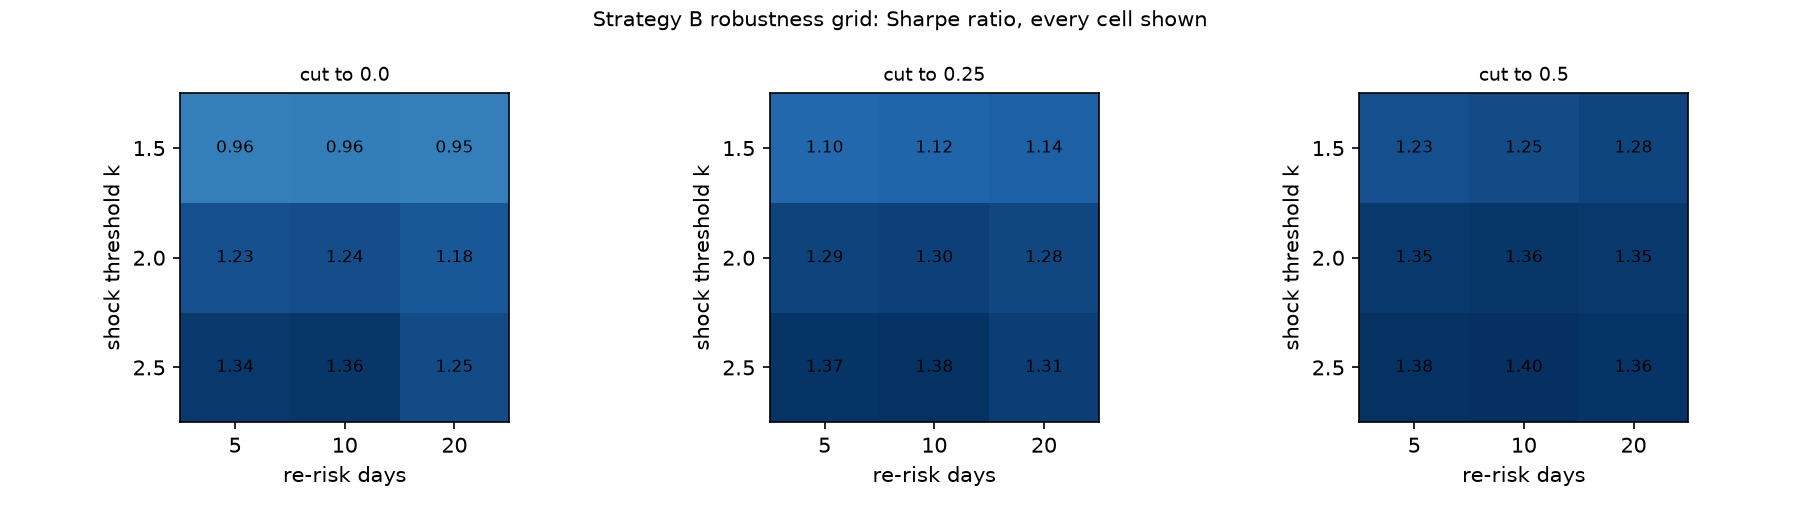

In [18]:
display(Image(R + "figures/strategy_b_grid.png", width=900))

## 6. Robustness and placebos

Three placebos (spec 10.2), with which performance should collapse:
- **(a)** signal dates shuffled within each month (100 draws);
- **(b)** contracts replaced by randomly drawn OTHER contracts, with random signs;
- **(c)** reversed sign.

They come with leave-one-event-out, parameter grids, equal weights, volume thresholds and sub-periods. The a posteriori additions have their own placebos (`results/robustness/posthoc.csv`).

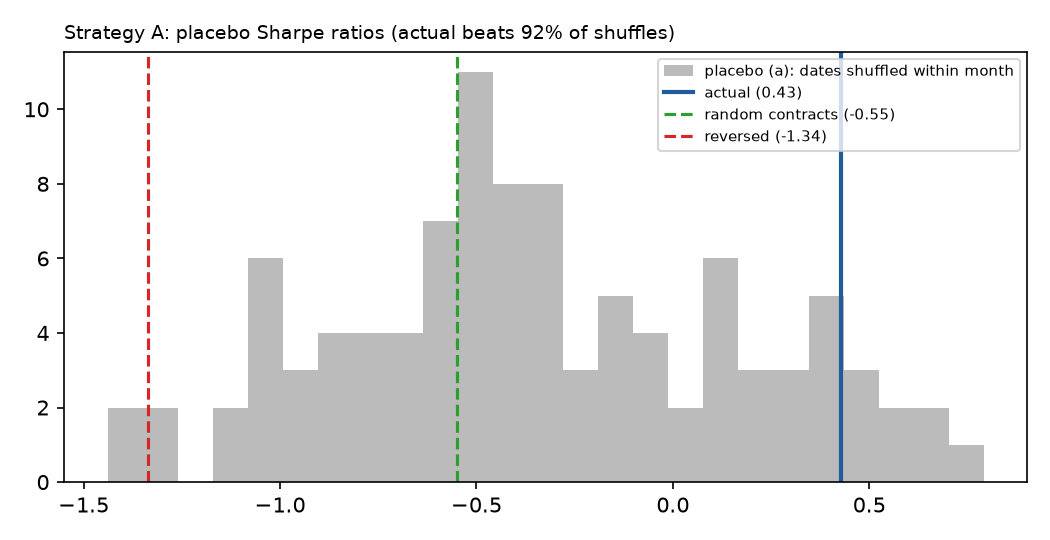

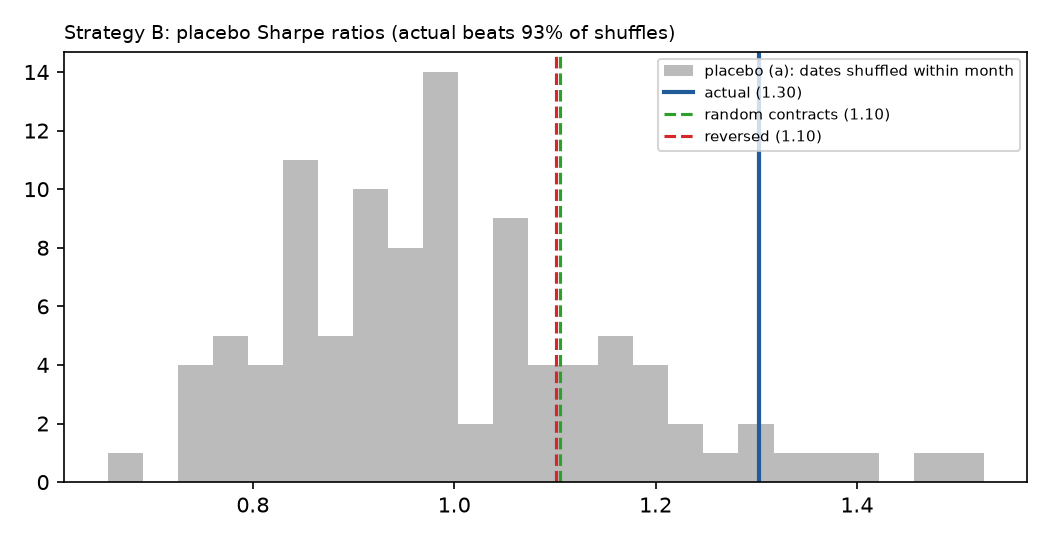


strategy_a A1: Sharpe by robustness exercise
                            count  mean   min   max
test                                               
actual                          1  0.43  0.43  0.43
equal_weights                   1  0.41  0.41  0.41
halflife                        4  0.15 -1.21  1.06
leave_one_event_out            10  0.42  0.23  0.63
placebo_a_shuffle             100 -0.34 -1.44  0.79
placebo_b_random_contracts      1 -0.55 -0.55 -0.55
placebo_c_reversed              1 -1.34 -1.34 -1.34

strategy_a A2: Sharpe by robustness exercise
                            count  mean   min   max
test                                               
actual                          1  0.81  0.81  0.81
equal_weights                   1  0.93  0.93  0.93
halflife                        4  0.33 -0.79  0.82
leave_one_event_out            10  0.81  0.68  1.14
placebo_a_shuffle             100 -0.22 -1.30  0.85
placebo_b_random_contracts      1 -0.30 -0.30 -0.30
placebo_c_reversed      

In [19]:
import glob
for f in sorted(glob.glob(R + "figures/*placebos.png")):
    display(Image(f, width=700))
for name in ("strategy_a", "strategy_b"):
    f = R + f"robustness/{name}.csv"
    if os.path.exists(f):
        t = pd.read_csv(f)
        if "variant" in t:
            for v in ("A1", "A2"):
                tv = t[(t["variant"] == v) & (~t["dollar_neutral"].astype(bool))]
                print(f"\n{name} {v}: Sharpe by robustness exercise")
                print(tv.groupby("test")["sharpe"].agg(["count", "mean", "min", "max"]).round(2))
        else:
            print(f"\n{name}: Sharpe by robustness exercise")
            print(t.groupby("test")["sharpe"].agg(["count", "mean", "min", "max"]).round(2))
ph = pd.read_csv(R + "robustness/posthoc.csv")
print("\nA posteriori additions: Sharpe by placebo")
print(ph.groupby(["strategy", "test"])["sharpe"].agg(["count", "mean", "min", "max"]).round(2))
print()
print(pd.read_csv(R + "robustness/subperiods.csv").round(2).to_string(index=False))

Reading the placebos:
- **A1, dollar leg**: the actual Sharpe beats 92% of the shuffled-date draws; random contracts and the reversed sign give negative Sharpes; leave-one-event-out is stable (0.23 to 0.63). The result remains **sensitive to the EWMA half-life**. Moderate evidence.
- **A2**: the actual Sharpe beats 99% of the draws; reversed sign: −2.06. This is the clearest evidence of Strategy A, with the multiple-testing caveat (several variants reported).
- **B, PM overlay**: it beats 93% of the shuffled-date draws. But the mean of those draws (0.99) is below the base carry (1.25): random cuts cost carry, and the actual rule does barely better than doing nothing. Leave-one-event-out on the ten largest events is stable, but the decisive event is a small 2024 contract that is not among them (D29).
- **A posteriori additions**: weekly A1 and D30 collapse with random contracts and the reversed sign; B2 beats its placebos but their mean stays below the base carry; the 3-event overlay (D31) does not beat random contracts or the reversed sign.
- **Sub-periods**: the advantage of the PM overlay is concentrated in 2024 (0.75 versus 0.22); it is negative in 2025 and nil in 2026.

## 7. Risk, leverage, liquidity, and A versus B

In [20]:
db = pd.read_csv(R + "risk/downside_beta.csv")
print("Normal and downside beta (Lettau, Maggiori, Weber), weekly, market MSCI World TR:")
print(db[db.strategy.isin(["base_carry", "pm_timed", "vix_timed", "A1_theory_with_dollar", "A2_theory_with_dollar"])
         & (db.market == "msci_world")].round(3).to_string(index=False))
print()
b = pd.read_csv(R + "risk/betas_weekly.csv")
print("Weekly betas (Newey-West t):")
print(b[b.strategy.isin(["base_carry", "A2_theory_with_dollar"])].round(3).to_string(index=False))
print()
print("Correlation of returns and drawdowns between A and B:")
c = pd.read_csv(R + "risk/a_vs_b_correlation.csv")
print(c[c.a.isin(["A1_theory_with_dollar", "A2_theory_with_dollar", "A1+S_theory_with_dollar"])].round(3).to_string(index=False))
print()
ep = pd.read_csv(R + "risk/episodes.csv")
print(ep[ep.strategy.isin(["base_carry", "pm_timed", "vix_timed", "A1_theory_with_dollar", "A2_theory_with_dollar"])]
      .pivot(index="episode", columns="strategy", values="cum_return").round(3))

Normal and downside beta (Lettau, Maggiori, Weber), weekly, market MSCI World TR:
             strategy     market   beta  downside_beta  n_down  mean_return_down_days_bp
A1_theory_with_dollar msci_world -0.057         -0.128      21                    25.275
A2_theory_with_dollar msci_world -0.243         -0.811      21                    70.825
           base_carry msci_world -0.024          0.000      21                    12.375
             pm_timed msci_world -0.038          0.035      21                     8.162
            vix_timed msci_world -0.018         -0.046      21                     5.870

Weekly betas (Newey-West t):
    factor   beta      t   n   corr              strategy
       spx -0.223 -1.982 143 -0.276 A2_theory_with_dollar
msci_world -0.243 -2.029 143 -0.277 A2_theory_with_dollar
     brent  0.013  0.503 143  0.044 A2_theory_with_dollar
    dollar  0.205  0.769 143  0.111 A2_theory_with_dollar
 g10_carry -0.103 -0.889 143 -0.107 A2_theory_with_dollar
  em_c

Reading:
- **A and B are distinct**: daily correlation of about −0.04, which meets the course requirement.
- **The 2024-2026 EM carry has no equity beta** (downside beta ≈ 0 against MSCI World). Its risk lies elsewhere: Brent (t ≈ 4.5) and G10 carry (t ≈ 3.5). This matches its composition (short KRW and CLP, which fall when oil rises; long COP). The course's equity crash risk shows in the long history (−44% drawdown), not in this window.
- **A2 behaves like a hedge**: MSCI beta of −0.24 (t ≈ −2), downside beta of −0.81, and it gains when VIX rises (t ≈ 2.7). It is long the dollar in stress periods.
- **Episodes**: A gains during the yen carry unwind (August 2024) and "Liberation Day" (April 2025), when B loses. Conversely, during the 2026 Iran war, A1 loses 7.5% and B gains 8%.

**Leverage and liquidity.** Leverage comes only from the 10% volatility target. Strategy A caps gross exposure at 3x and any pair at 30% of gross; Strategy B has no cap in its rule. Liquidity is measured by the strategy's own average forward half-spread.

In [21]:
lv = pd.read_csv(R + "risk/leverage.csv")
print(lv[lv.period == "2024-2026"][["strategy", "gross_mean", "gross_p95", "gross_max", "abs_net_usd_mean", "realised_vol",
                                   "share_days_gross_cap", "share_days_pair_cap"]].round(3).to_string(index=False))
cp = pd.read_csv(R + "risk/conditional_performance.csv")
lq = cp[(cp.conditioner == "half-spread tercile") & cp.strategy.isin(["A1_theory_with_dollar", "A2_theory_with_dollar", "base_carry", "pm_timed", "vix_timed"])]
print("\nSharpe by tercile of the strategy's own half-spread (q3 = least liquid):")
print(lq.pivot_table(index="bucket", columns="strategy", values="sharpe").round(2))

                    strategy  gross_mean  gross_p95  gross_max  abs_net_usd_mean  realised_vol  share_days_gross_cap  share_days_pair_cap
       A1_theory_with_dollar       1.734      2.279      3.166             1.734         0.105                 0.006                0.184
       A2_theory_with_dollar       1.868      2.997      3.158             1.640         0.102                 0.063                0.321
A1_theory_with_dollar_weekly       1.713      2.258      2.473             1.713         0.103                 0.000                0.187
                  base_carry       2.129      2.922      3.040             0.003         0.104                   NaN                  NaN
                    pm_timed       1.740      2.766      3.040             0.021         0.089                   NaN                  NaN
                   vix_timed       1.865      2.766      2.973             0.024         0.094                   NaN                  NaN
                 b2_oil_tilt      

Reading:
- **A1** is a pure dollar position (net USD exposure equals gross exposure, about 1.7x on average). The 30% per-pair cap binds on about 18% of days, because with the same signal on every pair the weight goes to the least volatile pair.
- **B** has almost no net dollar exposure (equal-size long and short legs). With no cap in the rule, gross exposure sometimes exceeds 3x, up to about 5x for B2, whose tilt adds to the carry.
- **Liquidity**: the carry earns most when EM markets are liquid (Sharpe about 2.4 in the low-spread tercile, about 0.6 in the high one), a liquidity-risk signature; the PM overlay does not protect in illiquid periods.

## 7b. Intraday lead-lag (D26, exploratory)

This analysis is **exploratory**, not pre-registered. It uses the top 1% hourly moves, selected mechanically: those of the G10 dollar basket (Dukascopy) and those of each PM index. For each event, the other market is followed from −6h to +6h, with values aligned on the sign of the event.

Hourly intervals are dated by their end time, on both sides. A significant mean at negative hours would mean that the other market moves **first**.

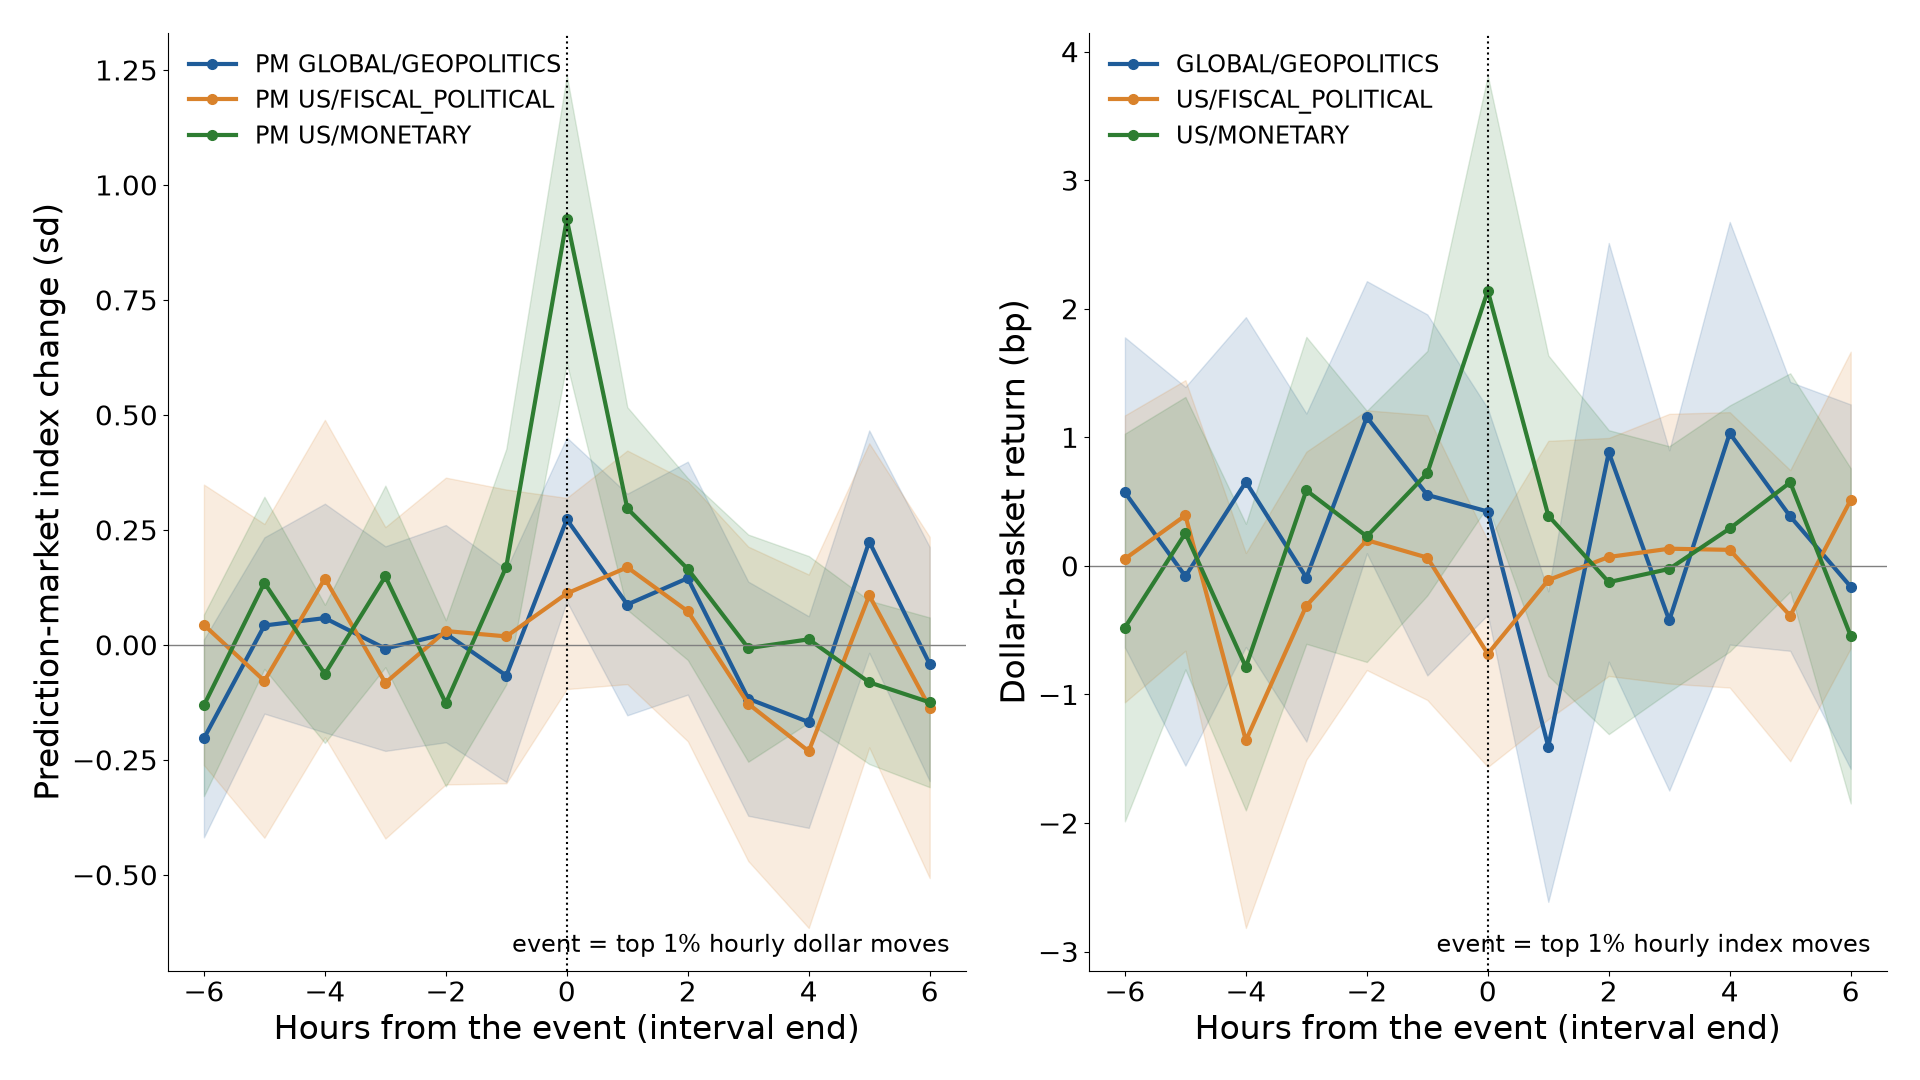

In [22]:
f = R + "figures/slides/slide_leadlag.png"
if os.path.exists(f):
    display(Image(f, width=950))
else:
    print("No Dukascopy hourly data.")

Reading: nothing moves before the event. Large dollar moves come with a move of US MONETARY **in the same hour and the next one**. The other way round, large PM moves are followed by no measurable FX move. At the hourly scale FX incorporates information at least as fast as prediction markets: this explains the lack of daily predictability and the null weekend test.

## 8. Backtest engine and automated tests

Conventions (spec 12):
- **Timing**: a position decided at the snapshot of t earns the return from t to t+1. Costs are paid on |w(t) − w(t−1)| × half-spread.
- **Volatility target**: EWMA covariance (span 60) known at t, gross leverage capped at 3, any pair at most 30% of gross exposure, 10% no-trade band.
- **FX excess return**: rx(t+1) = Δs(t+1) + carry(t)/252, with carry = (s − f) × 12.

The test suite covers:
- no look-ahead, daylight saving, causal inclusion;
- partition expected values and hazard rates, recomputed by hand;
- timing, costs, the no-trade band, the volatility target;
- the classification and timing rules.

In [23]:
import subprocess
r = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "--color=no", "-p", "no:cacheprovider"],
                   capture_output=True, text=True)
print(r.stdout.strip().splitlines()[-1])

58 passed in 3.52s


## 9. Conclusions and open points

**What the data show.**
- **A**: US prediction markets (mostly monetary policy) move with the dollar on the same day. A theory-signed rule with no estimation earns money before costs (A1: 0.88; A2: 1.43, t of 2.4), beats its placebos, and behaves like a hedge in stress periods. But there is no predictability at the spec's threshold, the weekend test is null, and costs at the Bloomberg bid/ask roughly halve the Sharpe. Weekly rebalancing recovers a good part of it (0.75 net). The 20-day gated rule on US FISCAL (D30) does not survive its checks (phase luck, insignificant effective-sample regression): an exploratory lead only.
- **B, EM carry with a PM geopolitical overlay**: the base carry works over the period. The overlay does not beat the base carry once a single 2024 contract is removed, nor with at least 3 events per day, and the reason is economic: this basket gains when oil rises. Replacing the cut by an oil tilt (B2) does not change the finding, and Brent does as well as prediction markets to trigger it.

**Open points.**

| Point | Status |
|---|---|
| Classification validation | 200 events to label (`ai_log/classification/validation_sheet_1.csv` to `_4.csv`) |
| 16:00 London fix (BFIX) | not requested: timing by closing time (D28) is enough; a new pull would only improve the contemporaneous regressions |
| Costs of A | Bloomberg closing spreads, conservative for NOK, SEK and CHF; sensitivity from 0.5x to 3x reported |
| HTML page | every series is exported to `results/site_data/` (D21) |

All decisions and their justification are in `DECISIONS.md`.